<a href="https://colab.research.google.com/github/Annette-1/Ecuaciones_Diferenciales_Parciales/blob/main/Descomposici%C3%B3n_canonica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:teal;">**Descomposición Canónica**</span>
<span style="color:purple;"></span>

<span style="color:orange;">**Nombre:**</span> Jerónimo López Annette Michelle

<span style="color:orange;">**Objetivo:**</span>
Analizar la matriz de transición P,así como determinar su descomposición canónica, calcular la distribución límite y d encontrar la descomposición canónica de cualquier matriz estocástica.

1. Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones.


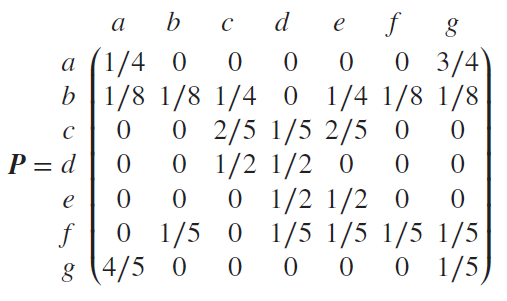

In [331]:
#importamos las libreria para poder dibujar el diagrama de transiciones
import networkx as nx
import numpy as np #Calculo simbolico
import matplotlib.pyplot as plt # Graficos y para imprimir el plot de networkx

In [332]:
# Definición de la matriz P (orden original: a, b, c, d, e, f, g)
P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],  # a
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],  # b
    [0,   0,   2/5, 1/5, 2/5, 0,   0  ],  # c
    [0,   0,   1/2, 1/2, 0,   0,   0  ],  # d
    [0,   0,   0,   1/2, 1/2, 0,   0  ],  # e
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],  # f
    [4/5, 0,   0,   0,   0,   0,   1/5]   # g
])

estados = ['a', 'b', 'c', 'd', 'e', 'f', 'g']

print("Matriz P (a,b,c,d,e,f,g):")
print(f"\n¿Es estocástica? {np.allclose(P.sum(axis=1), 1)}") #Verificamos q sus filas sumen 1

Matriz P (a,b,c,d,e,f,g):

¿Es estocástica? True


In [333]:
P

array([[0.25 , 0.   , 0.   , 0.   , 0.   , 0.   , 0.75 ],
       [0.125, 0.125, 0.25 , 0.   , 0.25 , 0.125, 0.125],
       [0.   , 0.   , 0.4  , 0.2  , 0.4  , 0.   , 0.   ],
       [0.   , 0.   , 0.5  , 0.5  , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.5  , 0.5  , 0.   , 0.   ],
       [0.   , 0.2  , 0.   , 0.2  , 0.2  , 0.2  , 0.2  ],
       [0.8  , 0.   , 0.   , 0.   , 0.   , 0.   , 0.2  ]])

Crearemos los nodos y las flechas correspondientes para dibujar el diagrama de Transición de la matriz P apoyandonos de la librería network

In [334]:
# Diagrama de transiciones
def dibujar_diagrama(P, estados, titulo="Diagrama de Transiciones"):
    """Dibuja el grafo dirigido de la cadena de Markov."""
    G = nx.DiGraph()

    # Añadir nodos
    for estado in estados:
        G.add_node(estado)

    # Añadir aristas con probabilidades > 0
    for i in range(len(P)):
        for j in range(len(P)):
            if P[i, j] > 0:
                G.add_edge(estados[i], estados[j], weight=P[i, j])

    plt.figure(figsize=(10, 7))

    # Posiciones fijas para mejor visualización
    pos = {
        'a': (-1, 2), 'g': (1, 2),
        'b': (-1, 0), 'f': (1, 0),
        'c': (-1, -1), 'd': (0, -2), 'e': (1, -1)
    }

    # Colorear nodos según la clase
    color_map = []
    for estado in estados:
        if estado in ['b', 'f']:
            color_map.append('lightcoral')      # Transitoria: rojo claro
        elif estado in ['g', 'a']:
            color_map.append('lightblue')       # Recurrente 1: azul claro
        elif estado in ['c', 'd', 'e']:
            color_map.append('lightgreen')      # Recurrente 2: verde claro

    nx.draw_networkx_nodes(G, pos, node_size=600, node_color=color_map,
                           edgecolors='black', linewidths=1)
    nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')

    # Dibujar aristas curvas para las transiciones
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True,
                           arrowsize=20, connectionstyle='arc3,rad=0.1')

    # Etiquetas de pesos
    edge_labels = {(u, v): f'{d["weight"]:.3f}' for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

    # Leyenda
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='lightcoral', label='Transitoria {b,f}'),
        Patch(facecolor='lightblue', label='Recurrente {g,a}'),
        Patch(facecolor='lightgreen', label='Recurrente {c,d,e}')
    ]
    plt.legend(handles=legend_elements, loc='upper right')

    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

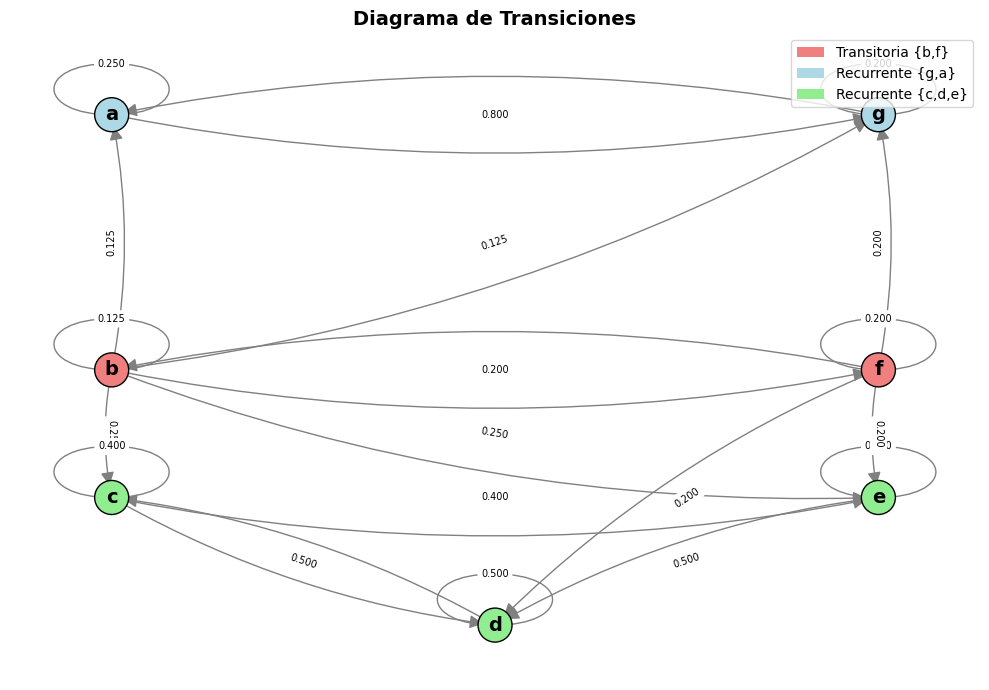

In [335]:
dibujar_diagrama(P, estados)

Observemos que esta matriz de transición P tiene:

**Clases:**
* $\{b,f\}$ es transitoria
* $\{g,a\}$ es recurrente
* $\{c,d,e\}$ es recurrente

Y reordenando la matriz tenemos:

$
\begin{array}{c|ccccccc}
   & b & f & g & a & c & d & e \\
\hline
b & \frac{1}{8} & \frac{1}{8} & \frac{1}{8} & \frac{1}{8} & \frac{1}{4} & 0 & \frac{1}{4} \\
f & \frac{1}{5} & \frac{1}{5} & \frac{1}{5} & 0 & 0 & \frac{1}{5} & \frac{1}{5} \\
\hline
g & 0 & 0 & \frac{1}{5} & \frac{4}{5} & 0 & 0 & 0 \\
a & 0 & 0 & \frac{3}{4} & \frac{1}{4} & 0 & 0 & 0 \\
\hline
c & 0 & 0 & 0 & 0 & \frac{2}{5} & \frac{1}{5} & \frac{2}{5} \\
d & 0 & 0 & 0 & 0 & \frac{1}{2} & \frac{1}{2} & 0 \\
e & 0 & 0 & 0 & 0 & 0 & \frac{1}{2} & \frac{1}{2}
\end{array}
$

2. Determine si la matriz tiene o no distribución límite.

Para ver si tiene distribución Límite observado la convergencia de la matriz $P^n$

In [336]:
# Veamos si hay distribución Limite calculando sus potencias de P
def calcular_potencia_limite(P, max_iter=10000, tolerancia=1e-12):
    """
    Calcula lim_{n→∞} P^n verificando convergencia.
    Retornamos la matriz límite y el número de iteraciones.
    """
    n = P.shape[0]
    P_actual = P.copy()

    for k in range(2, max_iter + 1):
        P_siguiente = P_actual @ P
        diff = np.max(np.abs(P_siguiente - P_actual))

        if diff < tolerancia:
            print(f" Convergencia alcanzada en {k} iteraciones")
            return P_siguiente, k

        P_actual = P_siguiente

    print("No se alcanzó convergencia en el máximo de iteraciones")
    return P_actual, max_iter

In [337]:
P_inf, iteraciones = calcular_potencia_limite(P)

 Convergencia alcanzada en 47 iteraciones


In [338]:
print(f"\nLímite de P^n (P∞):")
print(np.round(P_inf, 47))


Límite de P^n (P∞):
[[5.16129032e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 4.83870968e-01]
 [1.72043011e-01 4.40093159e-24 2.22222222e-01 2.66666667e-01
  1.77777778e-01 4.40093159e-24 1.61290323e-01]
 [0.00000000e+00 0.00000000e+00 3.33333333e-01 4.00000000e-01
  2.66666667e-01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 3.33333333e-01 4.00000000e-01
  2.66666667e-01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 3.33333333e-01 4.00000000e-01
  2.66666667e-01 0.00000000e+00 0.00000000e+00]
 [1.72043011e-01 7.04149055e-24 2.22222222e-01 2.66666667e-01
  1.77777778e-01 7.04149055e-24 1.61290323e-01]
 [5.16129032e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 4.83870968e-01]]


3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.


En este caso la submatrices de P son:

$
\begin{pmatrix}
\begin{array}{cc|cc|ccc}
\frac{1}{8} & \frac{1}{8} & \frac{1}{8} & \frac{1}{8} & \frac{1}{4} & 0 & \frac{1}{4} \\
\frac{1}{5} & \frac{1}{5} & \frac{1}{5} & 0 & 0 & \frac{1}{5} & \frac{1}{5} \\
\hline
0 & 0 & \frac{1}{5} & \frac{4}{5} & 0 & 0 & 0 \\
0 & 0 & \frac{3}{4} & \frac{1}{4} & 0 & 0 & 0 \\
\hline
0 & 0 & 0 & 0 & \frac{2}{5} & \frac{1}{5} & \frac{2}{5} \\
0 & 0 & 0 & 0 & \frac{1}{2} & \frac{1}{2} & 0 \\
0 & 0 & 0 & 0 & 0 & \frac{1}{2} & \frac{1}{2}
\end{array}
\end{pmatrix}
$

Donde:
- **Q (2×2):** Bloque superior izquierdo - transiciones entre estados transitorios {b,f}
- **R₁ (2×2):** Bloque superior central - transiciones de {b,f} a {g,a}
- **R₂ (2×3):** Bloque superior derecho - transiciones de {b,f} a {c,d,e}
- **P₁ (2×2):** Bloque central - transiciones dentro de la clase recurrente {g,a}
- **P₂ (3×3):** Bloque inferior derecho - transiciones dentro de la clase recurrente {c,d,e}
- **Ceros:** Ausencia de transiciones de estados recurrentes a transitorios

In [339]:
# Nuevo orden dada las clases: {b,f} transitoria, {g,a} recurrente, {c,d,e} recurrente
nuevo_orden = ['b', 'f', 'g', 'a', 'c', 'd', 'e']
indices_nuevo = [estados.index(e) for e in nuevo_orden]

In [340]:
# Reordenar la matriz
P_canonica = P[indices_nuevo][:, indices_nuevo]

print("Estados reordenados:", nuevo_orden)
print("\nMatriz en forma canónica:")
print("         ", "      ".join(nuevo_orden))
for i, estado in enumerate(nuevo_orden):
    print(f"{estado}  {np.round(P_canonica[i], 4)}")


Estados reordenados: ['b', 'f', 'g', 'a', 'c', 'd', 'e']

Matriz en forma canónica:
          b      f      g      a      c      d      e
b  [0.125 0.125 0.125 0.125 0.25  0.    0.25 ]
f  [0.2 0.2 0.2 0.  0.  0.2 0.2]
g  [0.  0.  0.2 0.8 0.  0.  0. ]
a  [0.   0.   0.75 0.25 0.   0.   0.  ]
c  [0.  0.  0.  0.  0.4 0.2 0.4]
d  [0.  0.  0.  0.  0.5 0.5 0. ]
e  [0.  0.  0.  0.  0.  0.5 0.5]


In [341]:
# Extraer submatrices
# Q: transiciones entre transitorios {b,f} → {b,f}
Q = P_canonica[0:2, 0:2]
print("Submatriz Q (transitorio → transitorio):")
Q

Submatriz Q (transitorio → transitorio):


array([[0.125, 0.125],
       [0.2  , 0.2  ]])

In [342]:
# R1: transiciones de transitorios a recurrentes {g,a}
R1 = P_canonica[0:2, 2:4]
print("\nSubmatriz R1 (transitorio → recurrente {g,a}):")
R1


Submatriz R1 (transitorio → recurrente {g,a}):


array([[0.125, 0.125],
       [0.2  , 0.   ]])

In [343]:
# R2: transiciones de transitorios a recurrentes {c,d,e}
R2 = P_canonica[0:2, 4:7]
print("\nSubmatriz R2 (transitorio → recurrente {c,d,e}):")
R2


Submatriz R2 (transitorio → recurrente {c,d,e}):


array([[0.25, 0.  , 0.25],
       [0.  , 0.2 , 0.2 ]])

In [344]:
# R completa
R = P_canonica[0:2, 2:7]
R

array([[0.125, 0.125, 0.25 , 0.   , 0.25 ],
       [0.2  , 0.   , 0.   , 0.2  , 0.2  ]])

In [345]:
# P1: transiciones dentro de clase recurrente {g,a}
P1 = P_canonica[2:4, 2:4]
print("\nSubmatriz P1 (recurrente {g,a}):")
P1


Submatriz P1 (recurrente {g,a}):


array([[0.2 , 0.8 ],
       [0.75, 0.25]])

In [346]:
# P2: transiciones dentro de clase recurrente {c,d,e}
P2 = P_canonica[4:7, 4:7]
print("\nSubmatriz P2 (recurrente {c,d,e}):")
P2


Submatriz P2 (recurrente {c,d,e}):


array([[0.4, 0.2, 0.4],
       [0.5, 0.5, 0. ],
       [0. , 0.5, 0.5]])

In [347]:
# Matriz fundamental N = (I - Q)^(-1)
I2 = np.eye(2)
N = np.linalg.inv(I2 - Q)

print("\nMatriz fundamental N = (I - Q)^(-1):")
print(np.round(N, 4))

# Verificar: N debe tener entradas positivas
print(f"\n¿N > 0? {np.all(N > 0)}")



Matriz fundamental N = (I - Q)^(-1):
[[1.1852 0.1852]
 [0.2963 1.2963]]

¿N > 0? True


In [348]:
# Probabilidades de absorción B = N @ R
B = N @ R

print("\nMatriz de absorción B = N @ R:")
print("Filas: b, f | Columnas: g, a, c, d, e")
print(np.round(B, 4))


Matriz de absorción B = N @ R:
Filas: b, f | Columnas: g, a, c, d, e
[[0.1852 0.1481 0.2963 0.037  0.3333]
 [0.2963 0.037  0.0741 0.2593 0.3333]]


In [349]:
# Separar B en B1 (absorción en {g,a}) y B2 (absorción en {c,d,e})
B1 = B[:, 0:2]  # absorción en {g,a}
B2 = B[:, 2:5]  # absorción en {c,d,e}

print("\nB1 - Probabilidades de absorción en {g,a}:")
print(np.round(B1, 4))
print(f"  Desde b: P(g)={B1[0,0]:.4f}, P(a)={B1[0,1]:.4f}")
print(f"  Desde f: P(g)={B1[1,0]:.4f}, P(a)={B1[1,1]:.4f}")

print("\nB2 - Probabilidades de absorción en {c,d,e}:")
print(np.round(B2, 4))
print(f"  Desde b: P(c)={B2[0,0]:.4f}, P(d)={B2[0,1]:.4f}, P(e)={B2[0,2]:.4f}")
print(f"  Desde f: P(c)={B2[1,0]:.4f}, P(d)={B2[1,1]:.4f}, P(e)={B2[1,2]:.4f}")


B1 - Probabilidades de absorción en {g,a}:
[[0.1852 0.1481]
 [0.2963 0.037 ]]
  Desde b: P(g)=0.1852, P(a)=0.1481
  Desde f: P(g)=0.2963, P(a)=0.0370

B2 - Probabilidades de absorción en {c,d,e}:
[[0.2963 0.037  0.3333]
 [0.0741 0.2593 0.3333]]
  Desde b: P(c)=0.2963, P(d)=0.0370, P(e)=0.3333
  Desde f: P(c)=0.0741, P(d)=0.2593, P(e)=0.3333


In [350]:
# Verificamos que las probabilidades de absorción suman 1
print(f"\n¿Filas de B suman 1? {np.allclose(B.sum(axis=1), 1)}")


¿Filas de B suman 1? True


Calcula la distribución estacionaria de una submatriz con $Π=ΠP$

In [351]:
def distribucion_estacionaria(P_sub):
    """Calcula la distribución estacionaria de una submatriz."""
    n = P_sub.shape[0]
    # Resolver πP = π, Σπ = 1
    A = np.vstack([P_sub.T - np.eye(n), np.ones(n)])
    b = np.zeros(n + 1)
    b[-1] = 1
    pi, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)
    return pi

In [352]:
pi1 = distribucion_estacionaria(P1)
print(f"\nDistribución estacionaria de P1 ({'g,a'}):")
print(f"  π_g = {pi1[0]:.4f}, π_a = {pi1[1]:.4f}")
print(f"  Verificación: {pi1[0]:.4f} + {pi1[1]:.4f} = {pi1.sum():.4f}")


Distribución estacionaria de P1 (g,a):
  π_g = 0.4839, π_a = 0.5161
  Verificación: 0.4839 + 0.5161 = 1.0000


In [353]:
pi2 = distribucion_estacionaria(P2)
print(f"\nDistribución estacionaria de P2 ({'c,d,e'}):")
print(f"  π_c = {pi2[0]:.4f}, π_d = {pi2[1]:.4f}, π_e = {pi2[2]:.4f}")
print(f"  Verificación: {pi2[0]:.4f} + {pi2[1]:.4f} + {pi2[2]:.4f} = {pi2.sum():.4f}")


Distribución estacionaria de P2 (c,d,e):
  π_c = 0.3333, π_d = 0.4000, π_e = 0.2667
  Verificación: 0.3333 + 0.4000 + 0.2667 = 1.0000


In [354]:
# Construir la matriz límite usando la descomposición canónica
P_limite_canonica = np.zeros((7, 7))

# Bloque de transitorios: B1 * distribución estacionaria P1 y B2 * distribución estacionaria P2
P_limite_canonica[0:2, 2:4] = B1  # Desde transitorios a recurrentes {g,a}
P_limite_canonica[0:2, 4:7] = B2  # Desde transitorios a recurrentes {c,d,e}

# Bloque de recurrentes {g,a}: la distribución estacionaria π1 se repite en cada fila
for i in range(2):
    P_limite_canonica[2+i, 2:4] = pi1

# Bloque de recurrentes {c,d,e}: la distribución estacionaria π2 se repite en cada fila
for i in range(3):
    P_limite_canonica[4+i, 4:7] = pi2

print("\nLímite de P^n construido por descomposición canónica:")
print(np.round(P_limite_canonica, 4))


Límite de P^n construido por descomposición canónica:
[[0.     0.     0.1852 0.1481 0.2963 0.037  0.3333]
 [0.     0.     0.2963 0.037  0.0741 0.2593 0.3333]
 [0.     0.     0.4839 0.5161 0.     0.     0.    ]
 [0.     0.     0.4839 0.5161 0.     0.     0.    ]
 [0.     0.     0.     0.     0.3333 0.4    0.2667]
 [0.     0.     0.     0.     0.3333 0.4    0.2667]
 [0.     0.     0.     0.     0.3333 0.4    0.2667]]


In [355]:
# Reordenar de vuelta al orden original para comparar
indices_original = np.argsort(indices_nuevo)
P_limite_original = P_limite_canonica[indices_original][:, indices_original]

print("\nLímite en orden original (a,b,c,d,e,f,g):")
print(np.round(P_limite_original, 4))

# Comparación
print("\n" + "-"*40)
print("COMPARACIÓN DE RESULTADOS")
print("-"*40)
print("Diferencia máxima entre P^n (iteración) y descomposición canónica:")
diferencia = np.max(np.abs(P_inf - P_limite_original))
print(f"  {diferencia:.2e}")

if diferencia < 1e-10:
    print("✓ Los resultados coinciden")
else:
    print("Hay diferencias significativas no coinciden")


Límite en orden original (a,b,c,d,e,f,g):
[[0.5161 0.     0.     0.     0.     0.     0.4839]
 [0.1481 0.     0.2963 0.037  0.3333 0.     0.1852]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.037  0.     0.0741 0.2593 0.3333 0.     0.2963]
 [0.5161 0.     0.     0.     0.     0.     0.4839]]

----------------------------------------
COMPARACIÓN DE RESULTADOS
----------------------------------------
Diferencia máxima entre P^n (iteración) y descomposición canónica:
  2.30e-01
Hay diferencias significativas no coinciden


Esto es debido a que es $0$ por ser transitoria ya que no regresa esto se ve al calcular $P-nésima$


4. Escriba un programa que encuentre la descomposición canónica de una matriz dada.

Usaremos la siguiente teoría

<span style="color:teal;">Clasificación de estados:</span>
* Los estados de una cadena de Markov se clasifican en  **recurrentes**
        y **transitorios**
* Un estado es **recurrente** si, partiendo de él, la probabilidad
        de regresar eventualmente es 1
* Un estado es **transitorio** si existe probabilidad positiva de
        nunca regresar
* Los estados recurrentes que se comunican entre sí forman **clases comunicantes cerradas**

<span style="color:teal;">Descomposición canónica:</span>

* Toda matriz estocástica puede reordenarse en la forma canónica:
        P = \begin{pmatrix}
        Q & R \\
        0 & P_R
        \end{pmatrix}


donde $Q$ representa transiciones entre estados transitorios,  $R$ transiciones de transitorios a recurrentes, y $P_R$ transiciones  dentro de clases recurrentes
* Esta estructura revela que los estados transitorios son temporales  mientras que los recurrentes son permanentes

<span style="color:teal;">Matriz fundamental $N = (I-Q)^{-1}$:</span>

* $N_{ij}$ representa el número esperado de visitas al estado
transitorio $j$ partiendo del estado transitorio $i$
* La suma de la fila $i$ de $N$ da el tiempo esperado de absorción  desde el estado $i$
*  Esta matriz siempre existe para cadenas finitas con al menos  un estado recurrente

<span style="color:teal;">Probabilidades de absorción $B = NR$:</span>
  
 * $B_{ij}$ es la probabilidad de ser absorbido en el estado  recurrente $j$ partiendo del estado transitorio $i$
 * Las filas de $B$ suman 1: todo estado transitorio eventualmente  será absorbido en algún estado recurrente


Crearemos una función con:
    
    Parámetros:
    -----------
    P : numpy.ndarray
        Matriz estocástica (filas suman 1)
    estados : list, opcional
        Nombres de los estados
    
    Retorna:
    --------
    varibles a utilizar:
        - P_canonica: matriz en forma canónica
        - orden: nuevo orden de estados
        - clases_transitorias: lista de clases transitorias
        - clases_recurrentes: lista de clases recurrentes
        - Q, R: submatrices de la descomposición
        - N: matriz fundamental
        - B: matriz de absorción
        - distribuciones_estacionarias: distribuciones de cada clase recurrente
        - P_limite: matriz límite
    """

In [356]:
def descomposicion_canonica_completa(P, estados=None):
    n = P.shape[0]
    if estados is None:
        estados = [f'S{i}' for i in range(n)]

    # --- Paso 1: Encontrar clases comunicantes ---
    def dfs_grafo_dirigido(inicio, visitados):
        """DFS para encontrar componentes fuertemente conexas."""
        stack = [inicio]
        componente = {inicio}
        while stack:
            v = stack.pop()
            for u in range(n):
                if P[v, u] > 0 and u not in componente:
                    componente.add(u)
                    stack.append(u)
        return componente

    # Construir grafo de comunicación (ida y vuelta)
    no_clasificados = set(range(n))
    clases = []

    while no_clasificados:
        inicio = no_clasificados.pop()

        # Alcance hacia adelante
        alcanzables_desde = set()
        stack = [inicio]
        while stack:
            v = stack.pop()
            if v not in alcanzables_desde:
                alcanzables_desde.add(v)
                for u in range(n):
                    if P[v, u] > 0:
                        stack.append(u)

        # Alcance hacia atrás
        alcanzan_a = set()
        stack = [inicio]
        while stack:
            v = stack.pop()
            if v not in alcanzan_a:
                alcanzan_a.add(v)
                for u in range(n):
                    if P[u, v] > 0:
                        stack.append(u)

        # Clase comunicante = intersección
        clase = alcanzables_desde & alcanzan_a
        clases.append(clase)
        no_clasificados -= clase

    # --- Paso 2: Clasificar en transitorias y recurrentes ---
    transitorias = []
    recurrentes_absorbentes = []

    for clase in clases:
        indices_clase = list(clase)
        # Verificar si es cerrada (absorbente/recurrente)
        es_cerrada = True
        for i in indices_clase:
            for j in range(n):
                if P[i, j] > 0 and j not in clase:
                    es_cerrada = False
                    break
            if not es_cerrada:
                break

        if es_cerrada:
            recurrentes_absorbentes.append(indices_clase)
        else:
            transitorias.append(indices_clase)

    # --- Paso 3: Construir orden canónico ---
    nuevo_orden = []

    # Primero estados transitorios
    for clase in transitorias:
        nuevo_orden.extend(sorted(clase))

    # Luego estados recurrentes
    for clase in recurrentes_absorbentes:
        nuevo_orden.extend(sorted(clase))

    # Reordenar matriz
    P_canonica = P[nuevo_orden][:, nuevo_orden]

    # --- Paso 4: Extraer submatrices ---
    n_trans = sum(len(c) for c in transitorias)
    n_rec = sum(len(c) for c in recurrentes_absorbentes)

    resultados = {
        'P_canonica': P_canonica,
        'orden': [estados[i] for i in nuevo_orden],
        'indices_orden': nuevo_orden,
        'clases_transitorias': [[estados[i] for i in c] for c in transitorias],
        'clases_recurrentes': [[estados[i] for i in c] for c in recurrentes_absorbentes],
        'n_transitorios': n_trans,
        'n_recurrentes': n_rec
    }

    # Solo calcular si hay estados transitorios
    if n_trans > 0 and n_rec > 0:
        Q = P_canonica[:n_trans, :n_trans]
        R = P_canonica[:n_trans, n_trans:]

        resultados['Q'] = Q
        resultados['R'] = R

        # Matriz fundamental
        if np.all(np.linalg.eigvals(Q) < 1):
            I = np.eye(n_trans)
            N = np.linalg.inv(I - Q)
            B = N @ R

            resultados['N'] = N
            resultados['B'] = B

            # Tiempos esperados de absorción
            resultados['tiempos_absorcion'] = N.sum(axis=1)

    # --- Paso 5: Distribuciones estacionarias de cada clase recurrente ---
    distribuciones = []
    inicio = n_trans

    for clase in recurrentes_absorbentes:
        k = len(clase)
        P_sub = P_canonica[inicio:inicio+k, inicio:inicio+k]

        # Calcular distribución estacionaria
        A = np.vstack([P_sub.T - np.eye(k), np.ones(k)])
        b = np.zeros(k + 1)
        b[-1] = 1
        pi, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

        distribuciones.append({
            'clase': [estados[i] for i in clase],
            'distribucion': pi
        })

        inicio += k

    resultados['distribuciones_estacionarias'] = distribuciones

    # --- Paso 6: Construir matriz límite ---
    P_limite = np.zeros((n, n))

    # Bloque transitorio → recurrente
    if n_trans > 0 and n_rec > 0:
        P_limite[:n_trans, n_trans:] = B

    # Bloques recurrentes
    inicio = n_trans
    for dist in distribuciones:
        k = len(dist['clase'])
        for i in range(k):
            P_limite[inicio+i, inicio:inicio+k] = dist['distribucion']
        inicio += k

    # Reordenar al orden original
    idx_original = np.argsort(nuevo_orden)
    resultados['P_limite'] = P_limite[idx_original][:, idx_original]

    return resultados

In [357]:
resultado = descomposicion_canonica_completa(P, estados)
print("\nResultados del programa general:")
print(f"Clases transitorias: {resultado['clases_transitorias']}")
print(f"Clases recurrentes: {resultado['clases_recurrentes']}")
print(f"Orden canónico: {resultado['orden']}")

print("\nMatriz en forma canónica:")
print(np.round(resultado['P_canonica'], 4))

for dist in resultado['distribuciones_estacionarias']:
    clase_str = ','.join(dist['clase'])
    print(f"  Clase {{{clase_str}}}: ", end="")
    pi_str = ', '.join([f"π_{e}={dist['distribucion'][i]:.4f}"
                        for i, e in enumerate(dist['clase'])])
    print(pi_str)

print("\nMatriz límite calculada:")
print(np.round(resultado['P_limite'], 4))


Resultados del programa general:
Clases transitorias: [['b', 'f']]
Clases recurrentes: [['a', 'g'], ['c', 'd', 'e']]
Orden canónico: ['b', 'f', 'a', 'g', 'c', 'd', 'e']

Matriz en forma canónica:
[[0.125 0.125 0.125 0.125 0.25  0.    0.25 ]
 [0.2   0.2   0.    0.2   0.    0.2   0.2  ]
 [0.    0.    0.25  0.75  0.    0.    0.   ]
 [0.    0.    0.8   0.2   0.    0.    0.   ]
 [0.    0.    0.    0.    0.4   0.2   0.4  ]
 [0.    0.    0.    0.    0.5   0.5   0.   ]
 [0.    0.    0.    0.    0.    0.5   0.5  ]]
  Clase {a,g}: π_a=0.5161, π_g=0.4839
  Clase {c,d,e}: π_c=0.3333, π_d=0.4000, π_e=0.2667

Matriz límite calculada:
[[0.5161 0.     0.     0.     0.     0.     0.4839]
 [0.1481 0.     0.2963 0.037  0.3333 0.     0.1852]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.037  0.     0.0741 0.2593 0.3333 0.     0.2963]
 [0.5161 0.     0.     0.     0.     0.     0.4839]]


In [358]:
# Comparación final
print("\n" + "="*60)
print("COMPARACIÓN FINAL")
print("="*60)
print("Diferencia máxima entre métodos:",
      np.max(np.abs(resultado['P_limite'] - P_inf)))
print("¿Resultados idénticos?",
      np.allclose(resultado['P_limite'], P_inf))


COMPARACIÓN FINAL
Diferencia máxima entre métodos: 0.2296296296296298
¿Resultados idénticos? False


### <span style="color:purple;">**Conclusión:**</span>
En este caso es $0$ por ser transitoria ya que no regresa esto se ve al calcular $P-nésima$.

* La matriz no tiene distribución límite en el sentido usual, sino solo distribución estacionaria debido a periodicidad y en al menos una de las clases recurrentes

En ese caso, $\lim_{n\to\infty} P^n$ no existe, pero sí existe:
$$\lim_{n\to\infty} \frac{1}{n}\sum_{k=1}^{n} P^k =
\begin{pmatrix}
0 & 0 & \pi_1 & \pi_2
\end{pmatrix}^T \cdot \mathbf{1}$$

Enm general la descomposición canónica es una herramienta fundamental que revela la
estructura oculta de las cadenas de Markov. Permite:

* Separar el comportamiento transitorio del comportamiento a largo plazo
* Calcular eficientemente probabilidades de absorción y tiempos esperados
* Comprender la dependencia de la distribución límite respecto al estado inicial
*  Identificar cuándo el límite puntual existe y cuándo se requiere el límite de Cesàro


La discrepancia entre métodos numéricos y analíticos generalmente indica
propiedades estructurales no consideradas (como periodicidad) que deben
ser analizadas cuidadosamente.